# Extraction of Information from the 35 papers - NeuroMorphs Systematic Review

After selecting and evaluating the papers for the development of the work entitled "In silico Neuronal Morphology Classification: A Systematic Review", this exploratory analysis was carried out. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
import requests
import io
warnings.filterwarnings("ignore")

C:\Users\jessi\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\jessi\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('files_csv/prep_neuron.csv')
df = df.iloc[:,1:]
df.head(3)

,work,Year,Publication_type,Cell-classes,Cell-types,How_many_classes/types_of_neurons?,What_type_of_classification_problems?,Region,Subregion,Species,What_is_the_data_source?,What_data_representation_is_being_used?,What_features_are_extracted?,What_classification_methods_are_being_used?,Types_of_ANN,What_neuroscience_tools_and_technologies_are_being_used?,Is_the_source_code_available?,What_programming_language_are_being_used?,What_evaluation_measures_are_being_used?,Other_relevant_aspects
0,"batabyal,t.,condron,b.,&_acton,s._t._(2020)._n...",2020,journal,"pyramidal,ganglion,granule,motoneuron,purkinje",only_classes,5_classes,multi-class,"neocortex,hippocampus","neocortex_occipital,neocortex_prefrontal,neoco...",mouse,neuromorpho,graph-based_,morphometrics_features,"knn,svm",does_not_use_ann,"neurosol,tmd,neuropath2path",yes._github_,matlab,"accuracy,confusion_matrix",path2path_is_being_compared_against_tmd_-_prop...
1,"grbatinic,i.,milosevic,n.,&_krstonosic,b._(201...",2018,journal,interneuron,caudate_(cin)_and_putaminal_neuron_type_(pin),"1_class,2_types",binary,neostriate_nuclei,neostriate_nuclei,human,own_dataset,"image-based,skeleton-based",morphometrics_features,"neural_networks,k-means,_linear_discriminant_a...","multi_layer_perceptron,kohonen_map",not_used,no,not_described,"auc,sensitivity",NaN
2,"kanari,l.,ramaswamy,s.,shi,y.,morand,s.,meystr...",2019,journal,pyramidal,not_described,"1_class,17_types",multi-class,somatosensory,cortex_somatosensory,rat,own_dataset,skeleton-based,"topological_features,morphometrics_features_",not_described,does_not_use_ann,tmd,no,not_described,"accuracy,confusion_matrix",they_do_a_reclassification._the_misclassified_...


## 1. Publications overview

### 1.1 Distribution by Year

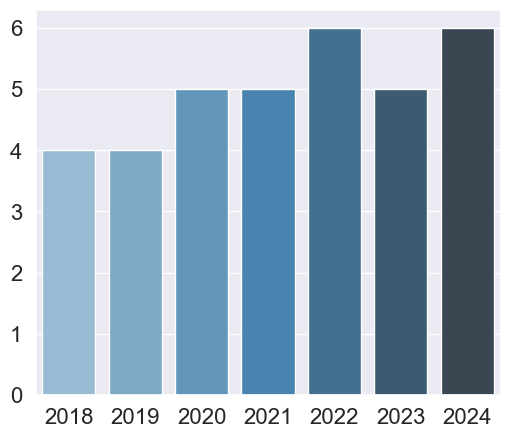

In [3]:
sns.set(style="darkgrid")
plt.figure(figsize=(6, 5))


ax = sns.countplot(data=df, x='Year', palette = 'Blues_d')


#plt.title('Study distribution by year', fontsize=16)
plt.xlabel('')
plt.ylabel('')
plt.tick_params(labelsize=16)

plt.savefig('imagens_english\years.png', bbox_inches = "tight")

plt.show()

### 1.2 Distribution by Publication type 

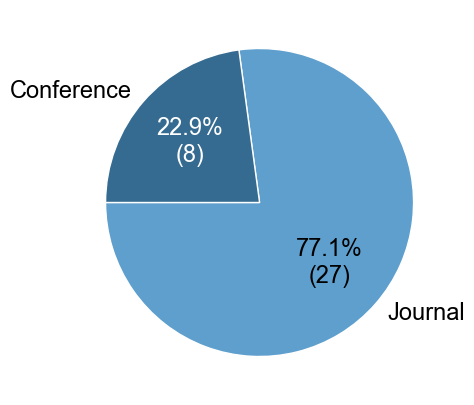

In [4]:
plt.figure(figsize=(5, 5))

publication_type_counts = df['Publication_type'].value_counts()

def format_pct(pct):
    total = sum(publication_type_counts)
    val = int(round(pct*total/100.0))
    return '{:.1f}%\n({:d})'.format(pct, val)

pie_chart = plt.pie(publication_type_counts, labels=['Journal', 'Conference'], 
                    autopct=format_pct, 
                    colors=sns.color_palette("Blues_d", n_colors=2), 
                    startangle=180, 
                    textprops={'color': 'black', 'fontsize': 17}) 


texts = pie_chart[2] 
texts[1].set_color('white')  # Change the color of the first text

plt.gca().set_aspect('equal')
#plt.title('b) Study distribution by publication type', fontsize=16)

plt.savefig('imagens_english\publication_types.png', bbox_inches = "tight")

plt.show()

## 2. Databases

In [5]:
import collections
from collections import Counter

#Transforming the column into a list
lista = df['What_is_the_data_source?'].tolist()

#Removing quotes from the list
lista1 = ','.join(lista).replace("'","")

#Dividing each line of the list using commas
palavras = lista1.split(',')

# Counting occurrences
contar_dataset = collections.Counter(palavras).most_common()

# Create a DataFrame from the Counter results
df_count = pd.DataFrame(contar_dataset, columns=['What_is_the_data_source?', 'Count'])

# Display the DataFrame
print(df_count)

dataset = [('NeuroMorpho.org', 19),
 ('Own Dataset', 9),
 ('Third Party', 5),
 ('Allen Cell Types', 4),
 ('Blue Brain Project', 2),       
 ('Others', 2),]

contar_dataset = Counter(palavras).most_common()
contar_dataset

  What_is_the_data_source?  Count
0              neuromorpho     19
1              own_dataset      9
2              third_party      5
3         allen_cell_types      4
4       blue_brain_project      2
5      brain_image_library      1
6       janelia_mouselight      1


[('neuromorpho', 19),
 ('own_dataset', 9),
 ('third_party', 5),
 ('allen_cell_types', 4),
 ('blue_brain_project', 2),
 ('brain_image_library', 1),
 ('janelia_mouselight', 1)]

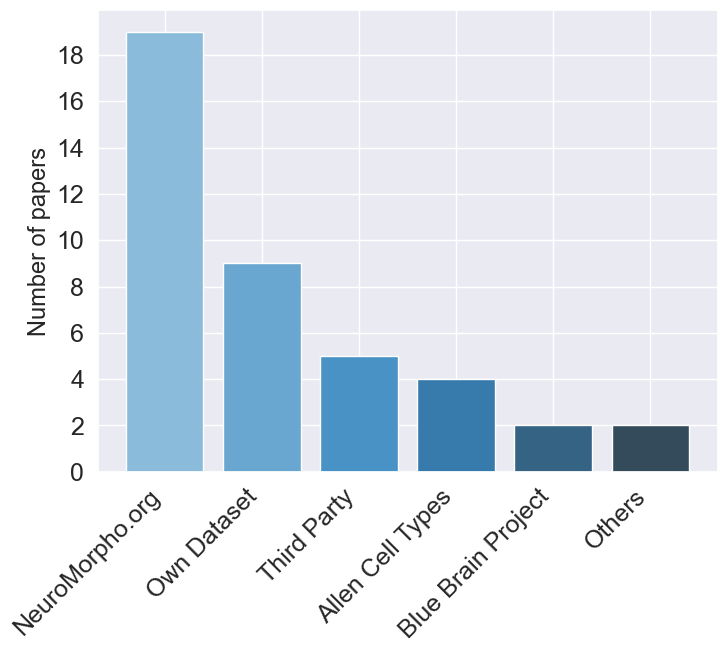

In [6]:
palette = sns.color_palette("Blues_d", n_colors=6)
sns.set(style="darkgrid")

plt.subplots(figsize=(8,6))

             
y_dataset = [palavra for Qty, palavra in dataset[:10]]
x_dataset = [Qty for Qty, palavra in dataset[:10]]

plt.bar(x_dataset, y_dataset, color=palette)
plt.title("", fontsize=17)
plt.ylabel("Number of papers", fontsize=17)
plt.xlabel("", fontsize=15)
plt.tick_params(labelsize=18)
plt.yticks(range(0, 20, 2))

plt.xticks(range(len(x_dataset)), x_dataset, rotation=45, ha='right')


plt.savefig('imagens_english/dataset.png', bbox_inches = "tight")

plt.show()

# 3. Cell-type

In [7]:
lista = df['Cell-classes'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

cell = [('Interneuron', 25),
 ('Pyramidal',22),
 ('Ganglion',11),
 ('Granule',11),
 ('Medium Spiny',10),
 ('Purkinje',9),
 ('Sensory',5),
 ('Motoneuron',4),
 ('Parachromaffin',4),
 ('Von Economo',2),
 ('Stellate',2),
 ('Cajal-retzius',1),
 ('Martinotti',1)]

#Using Counter library to count each element (word)
contar_cell= Counter(palavras).most_common()
contar_cell

[('interneuron', 25),
 ('pyramidal', 22),
 ('ganglion', 11),
 ('granule', 11),
 ('medium_spiny', 10),
 ('purkinje', 9),
 ('sensory', 5),
 ('not_described', 5),
 ('motoneuron', 4),
 ('parachromaffin', 4),
 ('von_economo', 2),
 ('stellate', 2),
 ('cajal-retzius', 1),
 ('martinotti', 1)]

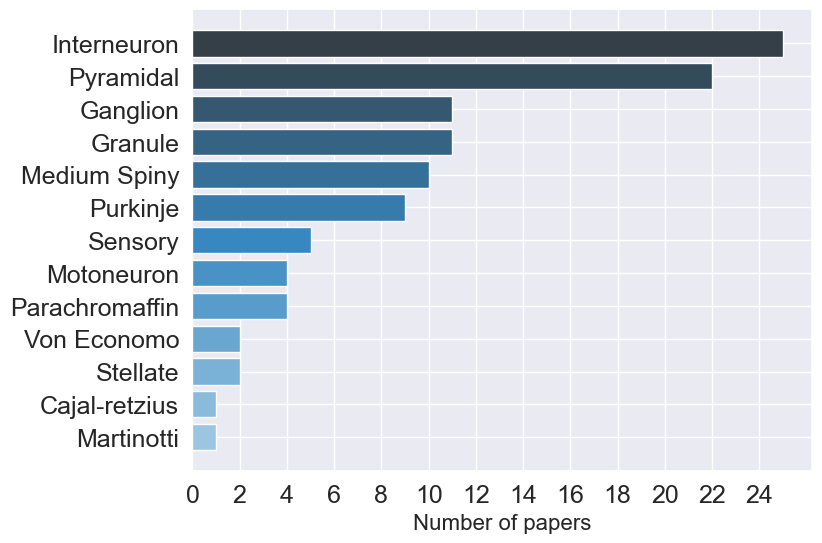

In [8]:
palette = sns.color_palette("Blues_d", n_colors=13)
sns.set(style="darkgrid")

plt.subplots(figsize=(8,6))
             
y_cell = [palavra for Qty, palavra in cell]
x_cell = [Qty for Qty, palavra in cell]

y_cell.reverse()
x_cell.reverse()

plt.barh(x_cell, y_cell, color=palette)
#plt.title("c) By cell-type", fontsize=18)
plt.ylabel("", fontsize=12)
plt.xlabel("Number of papers", fontsize=16)
plt.tick_params(labelsize=18)
plt.xticks(range(0, 25, 2))


plt.savefig('imagens_english/cell.png', bbox_inches = "tight")

plt.show()

# What type of classification problems?

In [9]:
df['What_type_of_classification_problems?'].unique()

#Transforming the column into a list
lista = df['What_type_of_classification_problems?'].tolist()

#Removing quotes from the list
lista1 = ','.join(lista).replace("'","")

#Dividing each line of the list using commas
palavras = lista1.split(',')

#Using Counter library to count each element (word)
contar_typeclass = Counter(palavras).most_common()
contar_typeclass

[('multi-class', 25),
 ('not_described', 5),
 ('binary', 4),
 ('not_identified', 1)]

# 4. Brain Region

In [11]:
#df['Region'].unique()

In [12]:
lista = df['Region'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

region = [('Neocortex', 12),
 ('Hippocampus', 7),
 ('Somatosensory', 5),
 ('Retina', 3),
 ('Cerebellum', 2),
 ('Spinal Cord', 1),
 ('Thalamus', 1),]

contar_region= Counter(palavras).most_common(10)
contar_region

[('not_described', 15),
 ('neocortex', 12),
 ('hippocampus', 7),
 ('somatosensory', 5),
 ('retina', 3),
 ('cerebellum', 2),
 ('neostriate_nuclei', 1),
 ('forebarin', 1),
 ('anterior_cingulate', 1),
 ('principal_olivary_nucleus', 1)]

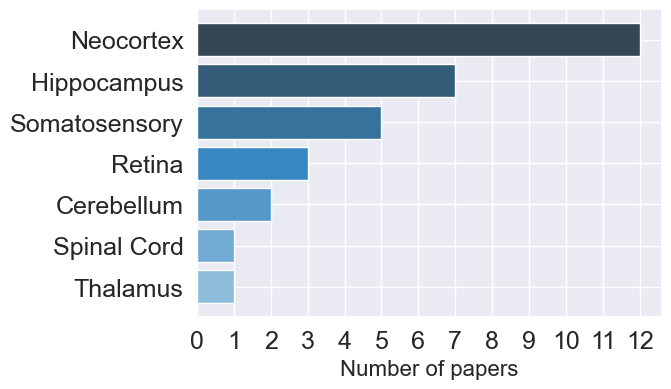

In [13]:
palette = sns.color_palette("Blues_d", n_colors=7)
sns.set(style="darkgrid")

plt.subplots(figsize=(6,4))
             
y_region = [palavra for Qty, palavra in region[:10]]
x_region = [Qty for Qty, palavra in region[:10]]

y_region.reverse()
x_region.reverse()

plt.barh(x_region, y_region, color=palette)
#plt.title("b) By brain region", fontsize=18)
plt.ylabel("", fontsize=15)
plt.xlabel("Number of papers", fontsize=16)
plt.tick_params(labelsize=18)
plt.xticks(range(0, 13, 1))


plt.savefig('imagens_english/regions.png', bbox_inches = "tight")

plt.show()

# Species

In [14]:
lista = df['Species'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

species = [('Mouse', 13),
 ('Rat', 13),
 ('Human', 9),
 ('Drosophila melanogaster', 4),
 ('Caenorhabditis elegans', 2),
 ('Wallaby', 1),
 ('Chimpanzee', 1),
 ('Monkey', 1),
 ('Danio rerio', 1),
 ('Ciona intestinalis', 1),]

contar_species= Counter(palavras).most_common(10)
contar_species

[('mouse', 13),
 ('rat', 13),
 ('human', 9),
 ('not_described', 6),
 ('drosophila_melanogaster', 4),
 ('caenorhabditis_elegans', 2),
 ('wallaby', 1),
 ('monkey', 1),
 ('zebrafish', 1),
 ('ciona_intestinalis', 1)]

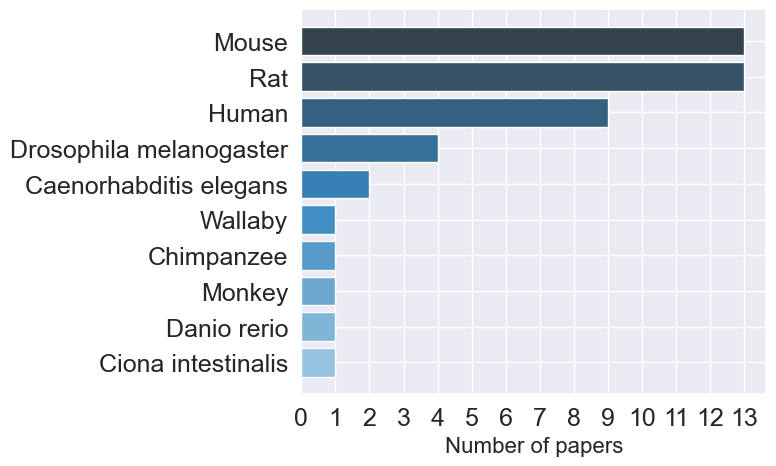

In [15]:
palette = sns.color_palette("Blues_d", n_colors=10)
sns.set(style="darkgrid")

plt.subplots(figsize=(6,5))
             
y_species = [palavra for Qty, palavra in species[:10]]
x_species = [Qty for Qty, palavra in species[:10]]

y_species.reverse()
x_species.reverse()

plt.barh(x_species, y_species, color=palette)
#plt.title("a) By specie", fontsize=18)
plt.ylabel("", fontsize=12)
plt.xlabel("Number of papers", fontsize=16)
plt.tick_params(labelsize=18)
plt.xticks(range(0, 14, 1))


plt.savefig('imagens_english/species.png', bbox_inches = "tight")

plt.show()

# 3. Classification Methods Used

In [16]:
lista = df['What_classification_methods_are_being_used?'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

clmet2 = [('Artificial Neural Networks', 21),
 ('Support Vector Machine', 13),
 ('K-Nearest Neighbors', 10),
 ('Random Forest', 8),
 ('Decision Tree', 8),
 ('Logistic Regression', 6),
 ('Naive Bayes', 5),
 ('K-means', 4),
 ('eXtreme Gradient Boosting', 3),         
 ('Linear Discriminant Analysis', 1),]

contar_clmet2 = Counter(palavras).most_common(14)
contar_clmet2

[('neural_networks', 17),
 ('svm', 13),
 ('knn', 10),
 ('decision_tree', 8),
 ('random_forest', 8),
 ('logistic_regression', 6),
 ('naive_bayes', 5),
 ('k-means', 4),
 ('_neural_networks', 4),
 ('not_described', 3),
 ('xgboost', 3),
 ('_linear_discriminant_analysis', 1),
 ('decision_stump', 1),
 ('lmnn', 1)]

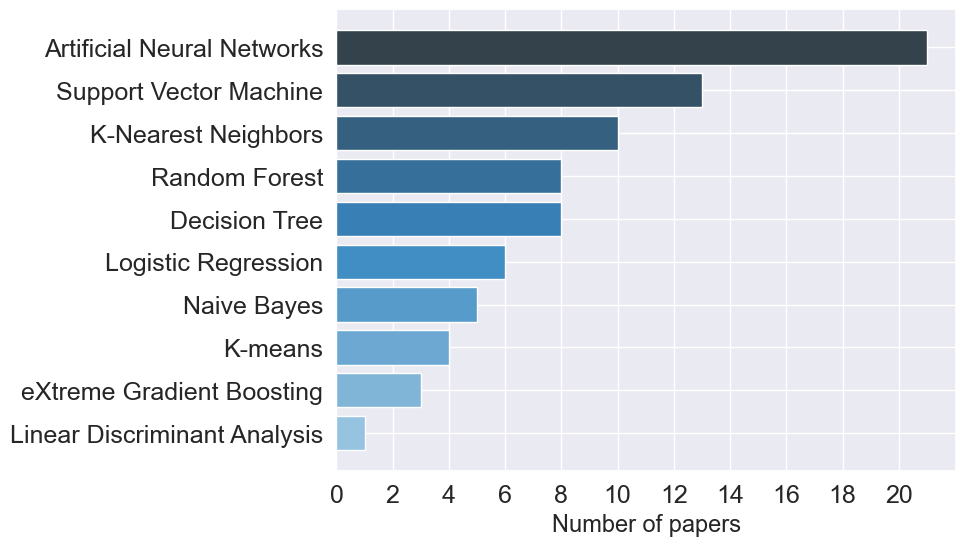

In [17]:
palette = sns.color_palette("Blues_d", n_colors=10)
sns.set(style="darkgrid")

plt.subplots(figsize=(8,6))
             
y_clmet2 = [palavra for Qty, palavra in clmet2[:10]]
x_clmet2 = [Qty for Qty, palavra in clmet2[:10]]

y_clmet2.reverse()
x_clmet2.reverse()

plt.barh(x_clmet2, y_clmet2, color=palette)
plt.title("", fontsize=17)
plt.ylabel("", fontsize=12)
plt.xlabel("Number of papers", fontsize=17)
plt.tick_params(labelsize=18)
plt.xticks(range(0, 22, 2))


plt.savefig('imagens_english\clmethods.png', bbox_inches = "tight")

plt.show()

## 3.1 What programming language are being used?

In [18]:
lista = df['What_programming_language_are_being_used?'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

#Using Counter library to count each element (word)
contar_lp = Counter(palavras).most_common()
contar_lp

[('not_described', 18), ('python', 11), ('matlab', 6)]

## 3.2 Is the source code available?

In [19]:
lista = df['Is_the_source_code_available?'].tolist()

#Removing quotes from the list
lista1 = ','.join(lista).replace("'","")

#Dividing each line of the list using commas
palavras = lista1.split(',')

#Using Counter library to count each element (word)
contar_c = Counter(palavras).most_common()
contar_c

[('no', 18),
 ('yes._github_', 10),
 ('no_', 2),
 ('no.', 2),
 ('yes._systems_neuroscience_group__erro_link', 1),
 ('yes._zenodo_', 1),
 ('yes._github', 1)]

## 3.3 Types ANN

In [20]:
lista = df['Types_of_ANN'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

contar_clmet = Counter(palavras).most_common()
contar_clmet

# Create a DataFrame from the Counter results
df_count = pd.DataFrame(contar_clmet, columns=['Types_of_ANN', 'Count'])

# Display the DataFrame
print(df_count)

                                        Types_of_ANN  Count
0                                   does_not_use_ann     14
1                       convolutional_neural_network      6
2                             long_short-term_memory      6
3                                             resnet      6
4                             multi_layer_perceptron      5
5                           recurrent_neural_network      5
6                                                vgg      4
7                       deep_residual_neural_network      3
8                               graph_neural_network      3
9                     fully_connected_neural_network      2
10                     locally_sparse_neural_network      2
11                                       kohonen_map      1
12  locally_cumulative_connected_deep_neural_network      1
13                                     not_described      1
14                                     inceptiontime      1
15                                      

In [21]:
ann = [('Long Short-Term Memory', 6),
        ('Residual Networks', 6),
 ('Convolutional Neural Networks', 6),
 ('Recurrent Neural Networks', 5),
 ('Multilayer Perceptron', 5),
 ('Visual Geometry Group', 4),
 ('Deep Recurrent Neural Network', 3),
 ('Graph Neural Network', 3),
 ('Fully Convolutional Neural Network', 2),         
 ('Kohonen Map', 1),]

contar_ann = Counter(palavras).most_common(10)
contar_ann

[('does_not_use_ann', 14),
 ('convolutional_neural_network', 6),
 ('long_short-term_memory', 6),
 ('resnet', 6),
 ('multi_layer_perceptron', 5),
 ('recurrent_neural_network', 5),
 ('vgg', 4),
 ('deep_residual_neural_network', 3),
 ('graph_neural_network', 3),
 ('fully_connected_neural_network', 2)]

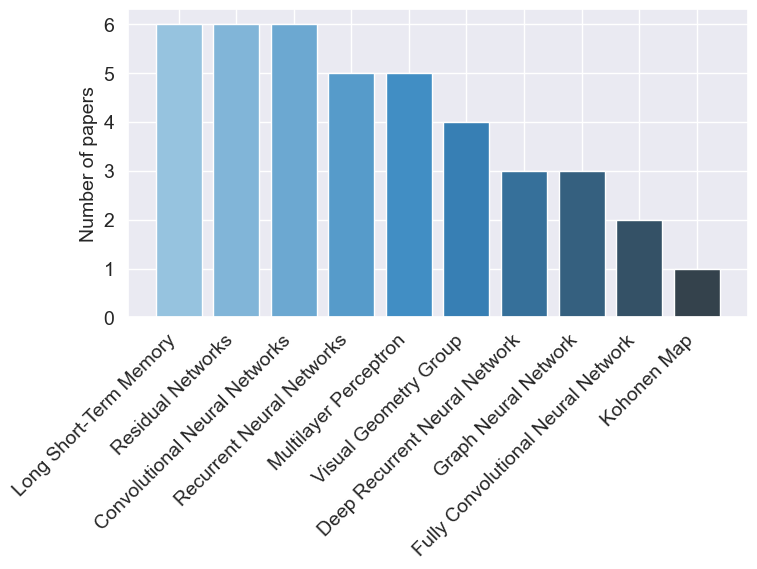

In [22]:
palette = sns.color_palette("Blues_d", n_colors=10)
sns.set(style="darkgrid")

plt.subplots(figsize=(8,4))
             
y_ann = [palavra for Qty, palavra in ann[:10]]
x_ann = [Qty for Qty, palavra in ann[:10]]


plt.bar(x_ann, y_ann, color=palette) 
plt.title("", fontsize=17)
plt.ylabel("Number of papers", fontsize=14)
plt.xlabel("", fontsize=15)
plt.tick_params(labelsize=14)
plt.xticks(range(0, 10, 1))

plt.xticks(range(len(x_ann)), x_ann, rotation=45, ha='right')


plt.savefig('imagens_english/ann.png', bbox_inches = "tight")

plt.show()

# 4. Data Representation

In [23]:
lista = df['What_data_representation_is_being_used?'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

contar_clmet = Counter(palavras).most_common()
contar_clmet

df_count = pd.DataFrame(contar_clmet, columns=['What_data_representation_is_being_used?', 'Count'])

print(df_count)

repre = [('Image-based', 13),
 ('Point-based', 8),
 ('Graph-based', 7),
 ('Skeleton-based', 3),     
 ('Voxel-based', 1),
 ('Sequence-based', 1),       
 ('Based on spike train', 1),
 ('Based on microscopy videos', 1),
 ('Patch-Clamp registry-based', 1),]

contar_repre = Counter(palavras).most_common()
contar_repre

  What_data_representation_is_being_used?  Count
0                             image-based     13
1                             point-based      8
2                             graph-based      4
3                            graph-based_      3
4                          skeleton-based      3
5              patch_clamp_registry-based      3
6                             voxel-based      1
7                    based_on_spike_train      1
8               based_on_microscopy_films      1
9                          sequence-based      1


[('image-based', 13),
 ('point-based', 8),
 ('graph-based', 4),
 ('graph-based_', 3),
 ('skeleton-based', 3),
 ('patch_clamp_registry-based', 3),
 ('voxel-based', 1),
 ('based_on_spike_train', 1),
 ('based_on_microscopy_films', 1),
 ('sequence-based', 1)]

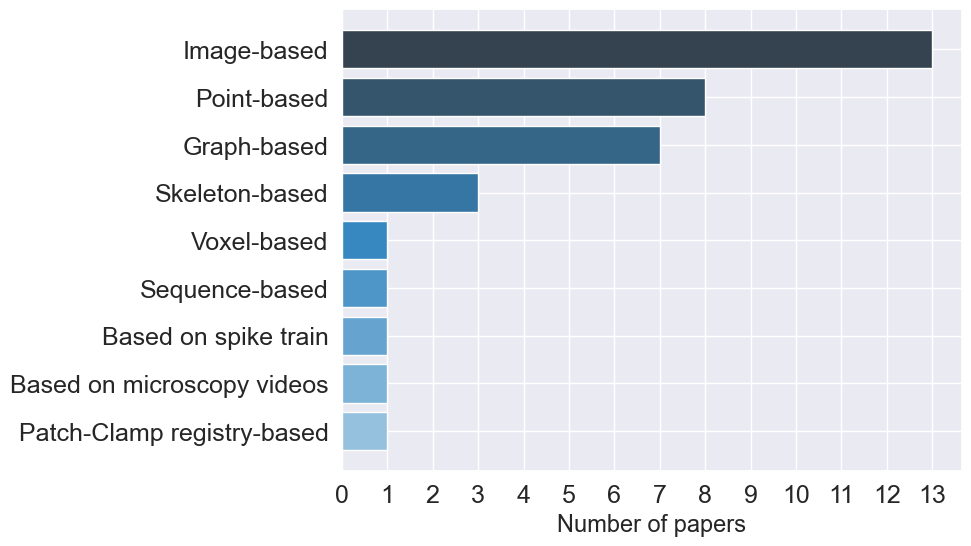

In [24]:
palette = sns.color_palette("Blues_d", n_colors=9)
sns.set(style="darkgrid")

plt.subplots(figsize=(8,6))
             
y_repre = [palavra for Qty, palavra in repre[:10]]
x_repre = [Qty for Qty, palavra in repre[:10]]

y_repre.reverse()
x_repre.reverse()

plt.barh(x_repre, y_repre, color=palette)
plt.title("", fontsize=17)
plt.ylabel("", fontsize=12)
plt.xlabel("Number of papers", fontsize=17)
plt.tick_params(labelsize=18)
plt.xticks(range(0, 14, 1))


plt.savefig('imagens_english/representation.png', bbox_inches = "tight")

plt.show()

### 4.1 Extract features of representations

In [28]:
lista = df['What_features_are_extracted?'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

#Using Counter library to count each element (word)
contar_clmet = Counter(palavras).most_common()
contar_clmet

# Create a DataFrame from the Counter results
df_count = pd.DataFrame(contar_clmet, columns=['What_features_are_extracted?', 'Count'])

# Display the DataFrame
print(df_count)

features = [('Morphometrics Features', 30),
 ('Topological Features', 5),
 ('Electrophysiological Features', 5),
 ('Density Maps ', 1),       
 ]

contar_features = Counter(palavras).most_common()
contar_features

    What_features_are_extracted?  Count
0         morphometrics_features     29
1  electrophysiological_features      5
2           topological_features      4
3        morphometrics_features_      1
4                   density_maps      1
5          topological_features_      1


[('morphometrics_features', 29),
 ('electrophysiological_features', 5),
 ('topological_features', 4),
 ('morphometrics_features_', 1),
 ('density_maps', 1),
 ('topological_features_', 1)]

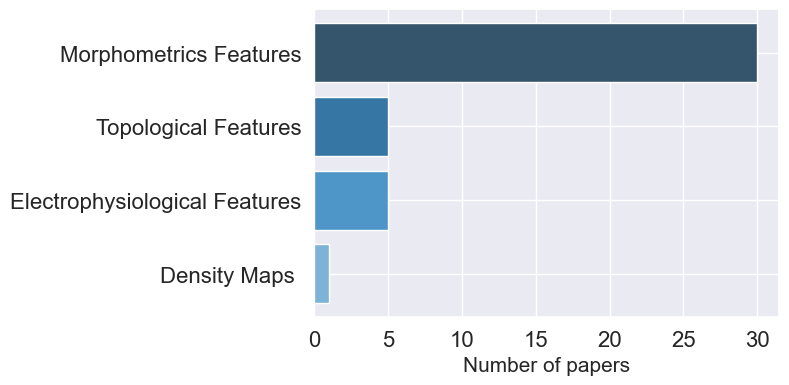

In [26]:
palette = sns.color_palette("Blues_d", n_colors=4)
sns.set(style="darkgrid")

plt.subplots(figsize=(6,4))
             
y_features = [palavra for Qty, palavra in features]
x_features = [Qty for Qty, palavra in features]

y_features.reverse()
x_features.reverse()

plt.barh(x_features, y_features, color=palette)
plt.title("", fontsize=17)
plt.ylabel("", fontsize=12)
plt.xlabel("Number of papers", fontsize=15)
plt.tick_params(labelsize=16)
plt.xticks(range(0, 35, 5))


plt.savefig('imagens_english/features.png', bbox_inches = "tight")

plt.show()

## 5. Evaluation Measures Used

In [29]:
lista = df['What_evaluation_measures_are_being_used?'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

#Using Counter library to count each element (word)
contar_clmet = Counter(palavras).most_common()
contar_clmet

# Create a DataFrame from the Counter results
df_count = pd.DataFrame(contar_clmet, columns=[' What_evaluation_measures_are_being_used?', 'Count'])

# Display the DataFrame
print(df_count)

measures = [('Accuracy ', 29),
 ('Confusion Matrix', 11),
 ('Area Under the Curve', 8),
 ('Precision', 7),
 ('F1-Score', 6),       
 ('Recall', 5),
 ('Sensitivity',2),
 ('Silhouette',1),
 ('Specificity',1)]

contar_measures = Counter(palavras).most_common()
contar_measures

    What_evaluation_measures_are_being_used?  Count
0                                   accuracy     29
1                           confusion_matrix     11
2                                        auc      8
3                                  precision      7
4                           cross-validation      6
5                                   f1-score      6
6                                     recall      5
7                                sensitivity      2
8                              not_described      2
9                                 silhouette      1
10                               specificity      1


[('accuracy', 29),
 ('confusion_matrix', 11),
 ('auc', 8),
 ('precision', 7),
 ('cross-validation', 6),
 ('f1-score', 6),
 ('recall', 5),
 ('sensitivity', 2),
 ('not_described', 2),
 ('silhouette', 1),
 ('specificity', 1)]

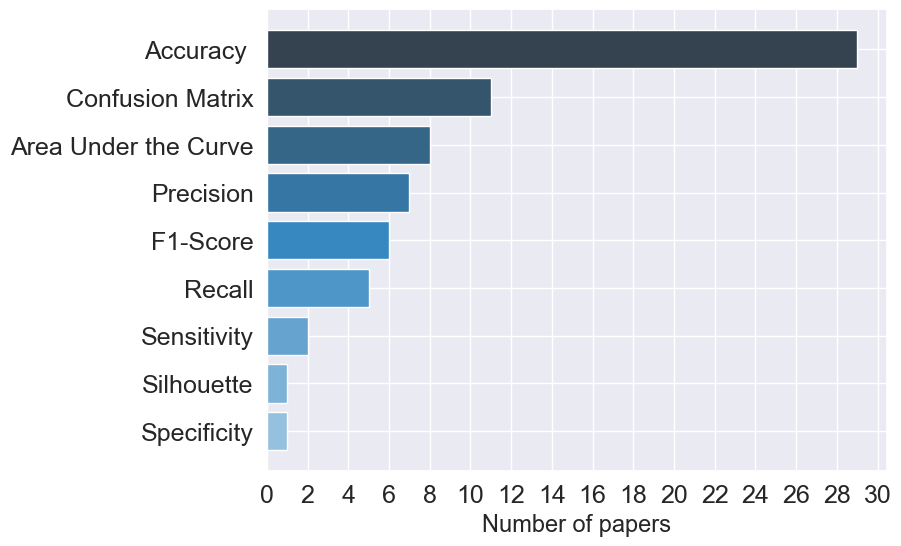

In [30]:
palette = sns.color_palette("Blues_d", n_colors=9)
sns.set(style="darkgrid")

plt.subplots(figsize=(8,6))
             
y_measures = [palavra for Qty, palavra in measures]
x_measures = [Qty for Qty, palavra in measures]

y_measures.reverse()
x_measures.reverse()

plt.barh(x_measures, y_measures, color=palette)
plt.title("", fontsize=17)
plt.ylabel("", fontsize=12)
plt.xlabel("Number of papers", fontsize=17)
plt.tick_params(labelsize=18)
plt.xticks(range(0, 32, 2))


plt.savefig('imagens_english/measures.png', bbox_inches = "tight")

plt.show()

# 6. Tools and tecnhologies most used

In [31]:
lista = df['What_neuroscience_tools_and_technologies_are_being_used?'].tolist()

lista1 = ','.join(lista).replace("'","")

palavras = lista1.split(',')

#Using Counter library to count each element (word)
contar_tools = Counter(palavras).most_common()
contar_tools

# Create a DataFrame from the Counter results
df_count = pd.DataFrame(contar_tools, columns=['What_neuroscience_tools_and_technologies_are_being_used?', 'Count'])

# Display the DataFrame
print(df_count)

tools = [('L-Measure ', 12),
 ('Topological Morphology Descriptor', 7),
 ('NeuroPath2Path', 3),
 ('CVAPP', 3),
 ('Neuromantic', 3),       
 ('TREES toolbox', 3),
 ('Neurolucida', 2),
 ('NLMorphologyConverter', 1),
 ('Vaa3D', 1),]

contar_tools = Counter(palavras).most_common()
contar_tools

   What_neuroscience_tools_and_technologies_are_being_used?  Count
0                                           l-measure           12
1                                            not_used           10
2                                                 tmd            7
3                                      neuropath2path            3
4                                               cvapp            3
5                                         neuromantic            3
6                                         neurolucida            2
7                                      sholl_analysis            2
8                                       trees_toolbox            2
9                                            neurosol            1
10                              nlmorphologyconverter            1
11                                         neuroncalc            1
12                                               hcga            1
13                                             neuron         

[('l-measure', 12),
 ('not_used', 10),
 ('tmd', 7),
 ('neuropath2path', 3),
 ('cvapp', 3),
 ('neuromantic', 3),
 ('neurolucida', 2),
 ('sholl_analysis', 2),
 ('trees_toolbox', 2),
 ('neurosol', 1),
 ('nlmorphologyconverter', 1),
 ('neuroncalc', 1),
 ('hcga', 1),
 ('neuron', 1),
 ('netgen', 1),
 ('vaa3d', 1),
 ('neurograph', 1),
 ('caiman', 1),
 ('treemoco', 1),
 ('morphvae', 1),
 ('morphognn', 1),
 ('', 1),
 ('tree_toolbox', 1)]

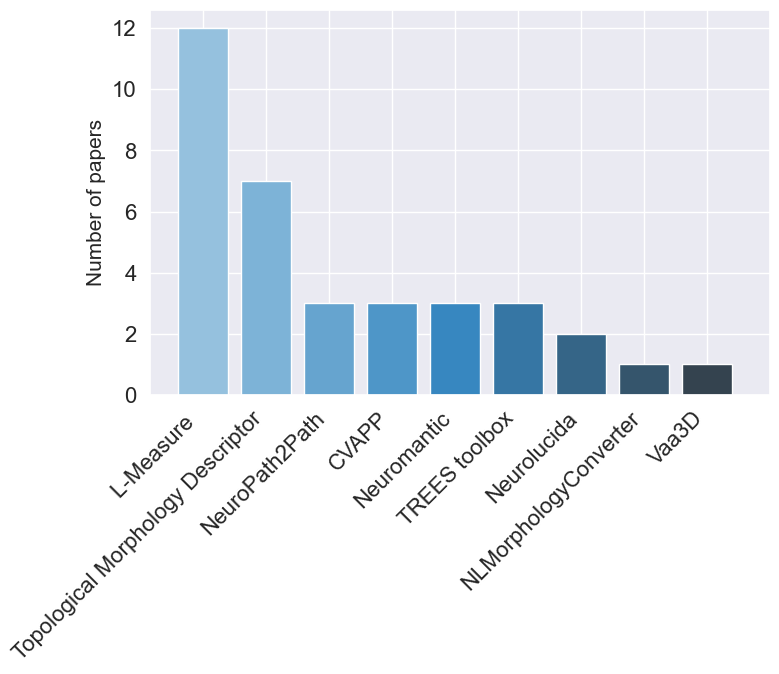

In [32]:
palette = sns.color_palette("Blues_d", n_colors=9)
sns.set(style="darkgrid")

plt.subplots(figsize=(8,5))
             
y_tools = [palavra for Qty, palavra in tools[:10]]
x_tools = [Qty for Qty, palavra in tools[:10]]



plt.bar(x_tools, y_tools, color=palette)
plt.title("", fontsize=17)
plt.ylabel("Number of papers", fontsize=15)
plt.xlabel("", fontsize=15)
plt.tick_params(labelsize=16)
plt.xticks(range(0, 10, 3))

plt.xticks(range(len(x_tools)), x_tools, rotation=45, ha='right')


plt.savefig('imagens_english/tools.png', bbox_inches = "tight")

plt.show()